# Baseline models
#### Previous notebook: [Data provisioning](02_data_provisioning.ipynb)

#### Models implemented in this notebook:
 - [Logistic Regression](#logistic-regression)
 - [Linear SVC](#linear-svc)
 - [Multinomial Naive Bayes](#multinomial-naive-bayes)

## Load train/val/test sets
In this step, I will load the files from the split_data folder to ensure that every model is trained, tuned and evaluated on exactly the same input texts and labels. To load the data, I will use the "load_split_data" function from the `helper.py` file:

In [3]:
from utilities import helper

X_train, X_val, X_test, y_train, y_val, y_test = helper.load_split_data(show = True)
labels = list(y_train.columns)

X_train: (12122,)
X_val: (3742,)
X_test: (3742,)
y_train: (12122, 5)
y_val: (3742, 5)
y_test: (3742, 5)


## Text normalization

In [4]:
from utilities.text_normalization import preprocess_text

X_train_norm = X_train.map(preprocess_text)
X_val_norm   = X_val.map(preprocess_text)
X_test_norm  = X_test.map(preprocess_text)

## Setting TF-IDF
In this step, I create a TF-IDF vectorizer configuration function to create a new vectorizer for each model. The TF-IDF vectorizer is used to measure how important a token is - tokens that are frequent in a message but not that frequent across the whole dataset, will be assigned with higher weights. Before tokenization and weighting, the text message is normalized by the `preprocess_text` function to ensure the consistency of the input format and reduce noise - the text is lowercased; URLs, emails, user mentions, hashtags and numbers are replaced with fixed placeholder tokens; extra white spaces are removed and spaCy lemmatization is applied to reduce the words to their base or dictionary form. After that, the text is tokenized by splitting on white spaces. The *ngram_range* uses both unigrams(single words) and bigrams(pair of 2 words) to capture short phrases, which might carry important information. Lasty, *min_df* and *max_df* are used to exclude very rare and too common tokens in order to reduce noise and improve generalization.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

def make_tfidf():
    return TfidfVectorizer(
        preprocessor=None,
        tokenizer=str.split,
        ngram_range=(1, 1),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=None
    )

## Get model scores
Different models score their predictions in different ways - some give probabilities in the range 0-1, while others base their decisions on negative and positive scores. In this notebook I implement both types of models, which is why the function below checks which scoring method the model supports and returns the correct score matrix. These scores are later compared to a chosen threshold and converted into the final binary multi-label predictions:

In [6]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return scores

## Choose best threshold
In this step, I create a function to select the best threshold per label for turning the models' scores into final 0/1 predictions. The baseline models do not output direct binary labels - instead they output confidence scores. In the previous version of the notebook, I was selecting one threshold for all labels, which is not ideal as some labels are rarer than others. The function takes the real labels, the confidence scores and a list of thresholds. For each label, it tries each candidate threshold and converts the scores into 0/1 binary predictions. Then, it computes the F1 score for that label and stores the threshold with the highest F1. Finally, the function returns an array of thresholds and the best F1 for each label:

In [7]:
from sklearn.metrics import f1_score

def best_thresholds_per_label_from_scores(y_true, y_scores, thresholds):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    best_t = np.zeros(y_true.shape[1])
    best_f1 = np.zeros(y_true.shape[1])

    for j in range(y_true.shape[1]):
        yj = y_true[:, j]
        sj = y_scores[:, j]

        best_f1_j = -1.0
        best_t_j = thresholds[0]

        for t in thresholds:
            pred = (sj >= t).astype(int)
            f1 = f1_score(yj, pred, zero_division=0)
            if f1 > best_f1_j:
                best_f1_j = f1
                best_t_j = t

        best_t[j] = best_t_j
        best_f1[j] = best_f1_j

    return best_t, best_f1

## General tuning
The purpose of this function is to construct a model, train it, test different hyperparameter values and, for each value, find the best decision threshold, using the previous function (*best_thresholds_per_label_from_scores*). For each *param_grid* setting, it finds and saves the best threshold and micro F1-score. In the end, the function returns the parameter setting that achieved the highest micro F1-score, as well as a table presenting the results of all tested hyperparameters settings:

In [8]:
def general_tuning(X_train, y_train, X_val, y_val,make_pipeline_fn,param_grid,thresholds):
    rows = []

    for params in param_grid:
        model = make_pipeline_fn()
        model.set_params(**params)
        model.fit(X_train, y_train)

        y_scores = get_scores(model, X_val)
        best_t, best_f1_per_label = best_thresholds_per_label_from_scores(y_val, y_scores, thresholds)
        y_pred = (y_scores >= best_t.reshape(1, -1)).astype(int)
        val_micro = f1_score(y_val, y_pred, average="micro", zero_division=0)

        rows.append({
            **params,
            "val_micro_f1": float(val_micro),
            "thresholds_per_label": best_t.tolist(),
            "val_f1_per_label": best_f1_per_label.tolist(),
            "model": model
        })

    best = max(rows, key=lambda r: r["val_micro_f1"])
    return best, pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in rows])

## Evaluation
The purpose of the *evalute_model* function is to evaluate an already trained model. First, it gets the model's confidence scores and uses the selected threshold to convert them into binary predictions. After that it calculates the model's micro and macro F1-score, the Hamming loss and the micro Jaccard score, and saves them along with the model's name and threshold. Finally, it returns the results with the predicted labels:

In [9]:
from sklearn.metrics import hamming_loss, jaccard_score

def evaluate_model(model, X, y, thresholds_per_label, model_name):
    y_scores = get_scores(model, X)
    thr = np.asarray(thresholds_per_label, dtype=float)
    y_pred = (y_scores >= thr.reshape(1, -1)).astype(int)

    metrics_row = {
        "model": model_name,
        "thresholds_per_label": thr.tolist(),
        "micro_f1": float(f1_score(y, y_pred, average="micro", zero_division=0)),
        "macro_f1": float(f1_score(y, y_pred, average="macro", zero_division=0)),
        "hamming_loss": float(hamming_loss(y, y_pred)),
        "jaccard_micro": float(jaccard_score(y, y_pred, average="micro", zero_division=0)),
    }

    return metrics_row, y_pred

The evaluation metrics used in this project are specifically chosen for proper multi-label classification evaluation:
 - **Micro F1-score** - shows the overall performance of a model across all labels; works well with imbalanced dataset; could hide poor performance on rare labels
 - **Macro F1-score** - calculates the F1-score for all labels and averages the results, gives equal importance to each label, useful to show how a model performs on rare labels
 - **Hamming loss** - shows the fraction of incorrectly predicted labels, lower results show better performance
 - **Jaccard similarity** - measures the overlap between true and predicted labels, strict - predicting extra labels or missing true labels reduces the score, higher results show better performance

# Modeling
## Logistic Regression
In this step, I will create a function that returns a new unfitted model on each run, which makes hyperparameter tuning easier. First, I create a pipeline to ensure no data leakage is introduced. The first step in the pipeline is the TF-IDF vectorizer, which converts each input message into numerical features and ensures text normalization and consistency. Then, the model is wrapped into "OneVsRestClassifier", which is very important for multi-label classification problems - creates and trains separate Logistic Regression per label and combines the outputs for the final prediction. The hyperparameter C is used to control th regularization of the model - smaller values apply stronger regularization, bigger values allow the model to fit more closely on the data. The *class_weight* is set to balanced to help the model handle label imbalance - gives more weight to the minority class during training.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

def make_lr_pipe():
    return Pipeline([
    ("tfidf", make_tfidf()),
    ("clf", OneVsRestClassifier(LogisticRegression(max_iter=2000, class_weight="balanced")))
])

### Tuning model
In this step, I will use the *general_tuning* function to tune the Logistic Regression and find the threshold that gives the highest micro F1-score on the validation set. The *C_grid* list consists of smaller and larger numbers close to the default value to test different regularization strengths.

In [18]:
import numpy as np
from sklearn.model_selection import ParameterGrid

param_grid = list(ParameterGrid({
    "clf__estimator__C": [0.5, 1.0, 2.0],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.9, 0.95],
    "tfidf__sublinear_tf": [True, False],
}))
thresholds = np.arange(0.2, 0.81, 0.05)
best_lr, lr_results = general_tuning(X_train_norm, y_train, X_val_norm, y_val,make_pipeline_fn=make_lr_pipe,param_grid=param_grid,thresholds=thresholds)

print("Best LR params:", {k: best_lr[k] for k in best_lr if k not in ["model"]})
display(lr_results.sort_values("val_micro_f1", ascending=False).head(10))

Best LR params: {'clf__estimator__C': 2.0, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True, 'val_micro_f1': 0.631324004305705, 'thresholds_per_label': [0.7, 0.6499999999999999, 0.6499999999999999, 0.7499999999999998, 0.7], 'val_f1_per_label': [0.7542662116040956, 0.5491124260355029, 0.49122807017543857, 0.6923076923076923, 0.5587188612099644]}


,clf__estimator__C,tfidf__max_df,tfidf__min_df,tfidf__ngram_range,tfidf__sublinear_tf,val_micro_f1,thresholds_per_label,val_f1_per_label
34,2.0,0.90,1,"(1, 2)",True,0.631324,"[0.7, 0.6499999999999999, 0.6499999999999999, ...","[0.7542662116040956, 0.5491124260355029, 0.491..."
42,2.0,0.95,1,"(1, 2)",True,0.631324,"[0.7, 0.6499999999999999, 0.6499999999999999, ...","[0.7542662116040956, 0.5491124260355029, 0.491..."
47,2.0,0.95,2,"(1, 2)",False,0.630232,"[0.5499999999999999, 0.6499999999999999, 0.7, ...","[0.7628361858190709, 0.5349397590361445, 0.496..."
39,2.0,0.90,2,"(1, 2)",False,0.630232,"[0.5499999999999999, 0.6499999999999999, 0.7, ...","[0.7628361858190709, 0.5349397590361445, 0.496..."
31,1.0,0.95,2,"(1, 2)",False,0.629630,"[0.5499999999999999, 0.5999999999999999, 0.649...","[0.7615947925142392, 0.5381984036488028, 0.499..."
23,1.0,0.90,2,"(1, 2)",False,0.629630,"[0.5499999999999999, 0.5999999999999999, 0.649...","[0.7615947925142392, 0.5381984036488028, 0.499..."
38,2.0,0.90,2,"(1, 2)",True,0.628648,"[0.5999999999999999, 0.6499999999999999, 0.7, ...","[0.7593671940049959, 0.5341317365269461, 0.498..."
46,2.0,0.95,2,"(1, 2)",True,0.628648,"[0.5999999999999999, 0.6499999999999999, 0.7, ...","[0.7593671940049959, 0.5341317365269461, 0.498..."
7,0.5,0.90,2,"(1, 2)",False,0.628481,"[0.5499999999999999, 0.5999999999999999, 0.599...","[0.7635467980295566, 0.5405405405405406, 0.484..."
15,0.5,0.95,2,"(1, 2)",False,0.628481,"[0.5499999999999999, 0.5999999999999999, 0.599...","[0.7635467980295566, 0.5405405405405406, 0.484..."


The tuning results show that the model scored the highest micro F1-score (0.62) with regularization strength of 2.0 and threshold of nearly 0.55. This suggests that the model performs best on this multi-label classification task with slightly weaker regularization and a threshold just above the default 0.5, which helps balance precision and recall.

### Evaluation
In this step, I will evaluate the performance of the best model using the evaluate function explained in the beginning of the notebook. After that, I will print a classification report to visualise the perfomance of the model on each label separately:

In [19]:
from sklearn.metrics import classification_report
import pandas as pd

results, y_test_pred = evaluate_model( best_lr["model"], X_test_norm, y_test, best_lr["thresholds_per_label"], "Logistic Regression")
lr_df = pd.DataFrame([results])
lr_df.to_csv("../data/results/logistic_regression_results.csv", index=False)
display(lr_df)
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=labels, zero_division=0))

,model,thresholds_per_label,micro_f1,macro_f1,hamming_loss,jaccard_micro
0,Logistic Regression,"[0.7, 0.6499999999999999, 0.6499999999999999, ...",0.619276,0.591256,0.07643,0.448515


Classification report:
                     precision    recall  f1-score   support

need_basic_supplies       0.72      0.77      0.75       576
  need_medical_help       0.57      0.55      0.56       433
 need_safety_rescue       0.50      0.44      0.47       269
       need_shelter       0.69      0.63      0.66       355
      people_status       0.59      0.47      0.53       295

          micro avg       0.64      0.60      0.62      1928
          macro avg       0.61      0.57      0.59      1928
       weighted avg       0.63      0.60      0.62      1928
        samples avg       0.23      0.22      0.22      1928



The results above show that the Logistic regression model achieves micro F1-score of 0.619, macro F1 - 0.591, hamming loss of 0.076 and Jaccard = 0.448. The small difference between the micro and macro F1-scores, suggests that the model performs slightly better with more common labels rather than the rare ones. The Hamming loss result shows that most label decisions are correct - lower incorrectly predicted label fraction. The Jaccard score shows moderate prediction between the true and predicted labels, probably because the model often predicts some correct labels per message but does not always match the full set perfectly. The classification report shows that the model performance best for the "need_basic_supplies" and struggles mostly with the "need_safety_rescue" label, which is probably due to the label imbalance and the fact that some words or phrases can overlap per label, making it harder to distinguish them.

## Linear SVC
Similarly to the previous model, in this step I will create a function that returns a new unfitted Linear SVC on each run. First in the pipeline is the TF-IDF vectorizer, which is used to apply the same text preprocessing and convert the input message into numerical features. Then, the model is wrapped in "OneVsRestClassifier" to create a linear SVC for each label and then combine all predictions in one. I assign the *class_weight* again to balanced to reduce the impact of label imbalance.

In [20]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

def make_svc_pipe():
    return Pipeline([
        ("tfidf", make_tfidf()),
        ("clf", OneVsRestClassifier(LinearSVC(class_weight="balanced", max_iter=2000)))
    ])

#### Tuning model
In this step, I will tune the linear SVC model similarly to the previous one. The difference here is that the model provides decision scores instead of probabilities. To create the threshold grid, I create 25 evenly placed points between the 5th and the 95th percentiles. Next, I use the *general_tuning* function to store and find the hyperparameter value and threshold that has the highest micro F1-score:

In [21]:
import numpy as np
from sklearn.model_selection import ParameterGrid
import pandas as pd

param_grid = list(ParameterGrid({
    "clf__estimator__C": [0.25, 0.5, 1.0, 2.0, 4.0],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.9, 0.95],
    "tfidf__sublinear_tf": [True, False],
}))

svc_probe = make_svc_pipe()
svc_probe.fit(X_train, y_train)
val_scores = get_scores(svc_probe, X_val)
q = np.linspace(1, 99, 41)
thresholds = np.unique(np.concatenate([np.percentile(val_scores[:, j], q)for j in range(val_scores.shape[1])]))
best_svc, svc_results = general_tuning(X_train_norm, y_train, X_val_norm, y_val,make_pipeline_fn=make_svc_pipe,param_grid=param_grid,thresholds=thresholds)

print("Best SVC params:", {k: best_svc[k] for k in best_svc if k not in ["model"]})
display(svc_results.sort_values("val_micro_f1", ascending=False).head(10))

Best SVC params: {'clf__estimator__C': 0.25, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': False, 'val_micro_f1': 0.6324740898219505, 'thresholds_per_label': [0.19310175100942226, 0.18940873646399595, 0.18940873646399595, 0.3355676494612319, 0.3210629797241438], 'val_f1_per_label': [0.7580511973575558, 0.5448195576251456, 0.4932562620423892, 0.6938775510204082, 0.5512104283054003]}


,clf__estimator__C,tfidf__max_df,tfidf__min_df,tfidf__ngram_range,tfidf__sublinear_tf,val_micro_f1,thresholds_per_label,val_f1_per_label
3,0.25,0.90,1,"(1, 2)",False,0.632474,"[0.19310175100942226, 0.18940873646399595, 0.1...","[0.7580511973575558, 0.5448195576251456, 0.493..."
11,0.25,0.95,1,"(1, 2)",False,0.632474,"[0.19310175100942226, 0.18940873646399595, 0.1...","[0.7580511973575558, 0.5448195576251456, 0.493..."
10,0.25,0.95,1,"(1, 2)",True,0.632292,"[0.19310175100942226, 0.19310175100942226, 0.1...","[0.7546862265688672, 0.544392523364486, 0.4922..."
2,0.25,0.90,1,"(1, 2)",True,0.632292,"[0.19310175100942226, 0.19310175100942226, 0.1...","[0.7546862265688672, 0.544392523364486, 0.4922..."
6,0.25,0.90,2,"(1, 2)",True,0.630210,"[0.11049455907516137, 0.18940873646399595, 0.3...","[0.7615894039735099, 0.5336481700118064, 0.497..."
14,0.25,0.95,2,"(1, 2)",True,0.630210,"[0.11049455907516137, 0.18940873646399595, 0.3...","[0.7615894039735099, 0.5336481700118064, 0.497..."
27,0.50,0.95,1,"(1, 2)",False,0.628998,"[0.19310175100942226, 0.18940873646399595, 0.1...","[0.7555923777961889, 0.5422116527942925, 0.502..."
19,0.50,0.90,1,"(1, 2)",False,0.628998,"[0.19310175100942226, 0.18940873646399595, 0.1...","[0.7555923777961889, 0.5422116527942925, 0.502..."
35,1.00,0.90,1,"(1, 2)",False,0.627159,"[0.19310175100942226, 0.18940873646399595, 0.1...","[0.7537688442211056, 0.5349693251533743, 0.513..."
43,1.00,0.95,1,"(1, 2)",False,0.627159,"[0.19310175100942226, 0.18940873646399595, 0.1...","[0.7537688442211056, 0.5349693251533743, 0.513..."


As we can see from above, the model score the highest micro F1-score with smaller regularization and a threshold of approximately 0.078. The results show that this model needs stronger regularization to perform better. Additionally, the threshold value looks small, just because the model does not output probabilities.

#### Evaluation
In this step, I will evaluate the performance of the best model using the evaluate function explained in the beginning of the notebook. After that, I will print a classification report to visualise the perfomance of the model on each label separately:

In [22]:
from sklearn.metrics import classification_report

results, y_test_pred = evaluate_model(best_svc["model"], X_test_norm, y_test, best_svc["thresholds_per_label"],"LinearSVC")

svm_df = pd.DataFrame([results])
svm_df.to_csv("../data/results/linear_svc_results.csv", index=False)

display(svm_df)
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=labels, zero_division=0))

,model,thresholds_per_label,micro_f1,macro_f1,hamming_loss,jaccard_micro
0,LinearSVC,"[0.19310175100942226, 0.18940873646399595, 0.1...",0.625555,0.595599,0.07659,0.455133


Classification report:
                     precision    recall  f1-score   support

need_basic_supplies       0.71      0.81      0.76       576
  need_medical_help       0.55      0.56      0.55       433
 need_safety_rescue       0.50      0.44      0.47       269
       need_shelter       0.68      0.66      0.67       355
      people_status       0.62      0.46      0.53       295

          micro avg       0.63      0.62      0.63      1928
          macro avg       0.61      0.59      0.60      1928
       weighted avg       0.63      0.62      0.62      1928
        samples avg       0.24      0.23      0.23      1928



Overall, the results above show that the model achieved micro F1 score of 0.625, macro F1-score of 0.595, Hamming loss of 0.076 and Jaccard score of 0.45. Similarly to the previous model, the Linear SVC performs better with more common labels. From the classification report, I can see that the SVC performs well with the "need_basic_supplies" and struggles with the "need_safety_rescue" label. Overall, the results show slightly better performance than the Logistic regression.

## Multinomial Naive Bayes
Multinomial Naive Bayes is a fast text classification model that presents a messages as a bag of word counts and uses the Bayes rule to determine a conditional probability of an event based on prior knowledge form the data and new evidence (the words in the message). The Bayes theorem is a mathematical formula used to outline important terms related to the concept of the target variable. The pipeline of this model stays consistent with the pipeline of the previous 2 models - first, the TF-IDF normalises the text and converts it into numerical vector of word weights, then the model is wrapped in "OneVSRestClassifier" to create multiple models per target variable:

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

def make_mnb_pipe():
    return Pipeline([
        ("tfidf", make_tfidf()),
        ("clf", OneVsRestClassifier(MultinomialNB()))
    ])

#### Tuning model
In this step, I will perform general tuning of the model. First, the hyperparameters for the TF-IDF and the model are tuned. These parameters control how strongly the model reacts to rare words and whether it learns how common a target variable. Next, I use the `best_thresholds_per_label_from_scores` function to find the best thresholds per label:

In [15]:
import numpy as np
from sklearn.model_selection import ParameterGrid
import pandas as pd

param_grid_mnb = list(ParameterGrid({
    "clf__estimator__alpha": [0.1, 0.3, 0.5, 1.0, 2.0],
    "clf__estimator__fit_prior": [True, False],
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.9, 0.95],
    "tfidf__sublinear_tf": [True, False]
}))

thresholds = np.arange(0.2, 0.81, 0.05)
best_mnb, mnb_results = general_tuning(X_train_norm, y_train, X_val_norm, y_val,make_pipeline_fn=make_mnb_pipe,param_grid=param_grid_mnb,thresholds=thresholds)

print("Best MNB params:", {k: best_mnb[k] for k in best_mnb if k not in ["model"]})
display(mnb_results.sort_values("val_micro_f1", ascending=False).head(10))

Best MNB params: {'clf__estimator__alpha': 0.3, 'clf__estimator__fit_prior': True, 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True, 'val_micro_f1': 0.5399370168909247, 'thresholds_per_label': [0.35, 0.3, 0.2, 0.2, 0.25], 'val_f1_per_label': [0.6631299734748011, 0.4833759590792839, 0.42436974789915966, 0.5501618122977346, 0.4444444444444444]}


,clf__estimator__alpha,clf__estimator__fit_prior,tfidf__max_df,tfidf__min_df,tfidf__ngram_range,tfidf__sublinear_tf,val_micro_f1,thresholds_per_label,val_f1_per_label
68,0.3,True,0.95,2,"(1, 2)",True,0.539937,"[0.35, 0.3, 0.2, 0.2, 0.25]","[0.6631299734748011, 0.4833759590792839, 0.424..."
56,0.3,True,0.90,2,"(1, 2)",True,0.539937,"[0.35, 0.3, 0.2, 0.2, 0.25]","[0.6631299734748011, 0.4833759590792839, 0.424..."
8,0.1,True,0.90,2,"(1, 2)",True,0.539245,"[0.44999999999999996, 0.35, 0.25, 0.35, 0.35]","[0.6601248884924175, 0.48994082840236686, 0.44..."
20,0.1,True,0.95,2,"(1, 2)",True,0.539245,"[0.44999999999999996, 0.35, 0.25, 0.35, 0.35]","[0.6601248884924175, 0.48994082840236686, 0.44..."
21,0.1,True,0.95,2,"(1, 2)",False,0.536705,"[0.44999999999999996, 0.35, 0.25, 0.35, 0.3]","[0.6607301869991096, 0.490521327014218, 0.4448..."
9,0.1,True,0.90,2,"(1, 2)",False,0.536705,"[0.44999999999999996, 0.35, 0.25, 0.35, 0.3]","[0.6607301869991096, 0.490521327014218, 0.4448..."
33,0.1,False,0.90,2,"(1, 2)",False,0.536692,"[0.7499999999999998, 0.7499999999999998, 0.799...","[0.6607301869991096, 0.4855072463768116, 0.449..."
45,0.1,False,0.95,2,"(1, 2)",False,0.536692,"[0.7499999999999998, 0.7499999999999998, 0.799...","[0.6607301869991096, 0.4855072463768116, 0.449..."
44,0.1,False,0.95,2,"(1, 2)",True,0.536585,"[0.7499999999999998, 0.5999999999999999, 0.799...","[0.6607142857142857, 0.48616600790513836, 0.44..."
32,0.1,False,0.90,2,"(1, 2)",True,0.536585,"[0.7499999999999998, 0.5999999999999999, 0.799...","[0.6607142857142857, 0.48616600790513836, 0.44..."


#### Evaluation

In [16]:
from sklearn.metrics import classification_report

results, y_test_pred = evaluate_model(best_mnb["model"], X_test_norm, y_test, best_mnb["thresholds_per_label"], "Multinomial Naive Bayes")
mnb_df = pd.DataFrame([results])
mnb_df.to_csv("../data/results/mnb_results.csv", index=False)
display(mnb_df)
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=labels, zero_division=0))

,model,thresholds_per_label,micro_f1,macro_f1,hamming_loss,jaccard_micro
0,Multinomial Naive Bayes,"[0.35, 0.3, 0.2, 0.2, 0.25]",0.520011,0.486585,0.090379,0.351362


Classification report:
                     precision    recall  f1-score   support

need_basic_supplies       0.64      0.64      0.64       576
  need_medical_help       0.56      0.41      0.47       433
 need_safety_rescue       0.45      0.32      0.38       269
       need_shelter       0.56      0.53      0.54       355
      people_status       0.55      0.31      0.40       295

          micro avg       0.57      0.48      0.52      1928
          macro avg       0.55      0.44      0.49      1928
       weighted avg       0.57      0.48      0.51      1928
        samples avg       0.19      0.18      0.18      1928



The model achieved a Micro f1 of 0.52, a Macro f1 of 0.48, a Hamming loss of 0.09 and Jaccard score of 0.35. Overall, the results show similar patterns with the previous 2 models, confirming that *people status* and *need_safety_rescue* are the hardest labels for the models to predict. The lower performance of the Multinomial Naive Bayes was expected because the of the way the model makes its predictions - it mostly relies on individual words and is less effective at capturing meaning that depends on phrases. Additionally, as we can see from the classification report the model performs best when the signal is dominated by few label specific keywords, while it struggles with labels such as *need_safety_rescue* which could be expressed in many different ways.

## Model Comparison

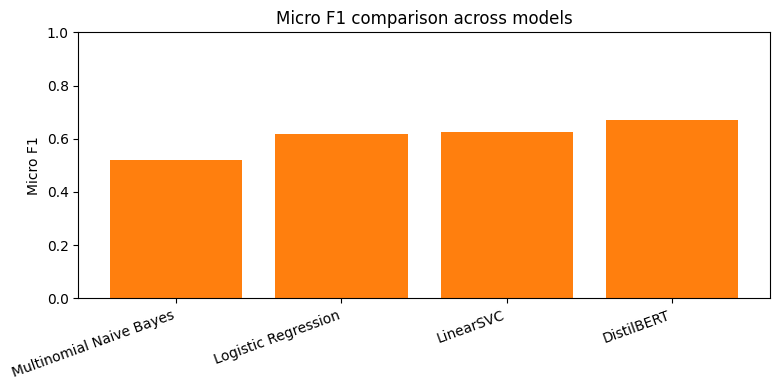

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

mnb   = pd.read_csv("../data/results/mnb_results.csv")
lr    = pd.read_csv("../data/results/logistic_regression_results.csv")
svc   = pd.read_csv("../data/results/linear_svc_results.csv")
bert  = pd.read_csv("../data/results/distilBert_results.csv")
df = pd.concat([mnb, lr, svc, bert], ignore_index=True)
micro = df[["model", "micro_f1"]].copy()

plt.figure(figsize=(8,4))
plt.bar(micro["model"], micro["micro_f1"], color="tab:orange")
plt.ylim(0, 1)
plt.ylabel("Micro F1")
plt.title("Micro F1 comparison across models")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

The bar chart above shows the current Micro f1 results for each model. The Multinomial Naive Bayes achieved the lowest Micro f1 score as it mainly relies on individual keyword rather than phrases and other word combinations, which limits its ability to capture contextual meaning. The Logistic Regression and Linear SVC show slightly improved results. Both models are able to learn which tokens increase and decrease the chance for each target variable, which allows them to combine multiple signals in one message. Additionaly, the similarity in the results reflects to the fact that they learned similar decision boundaries in the same feature space. Finally, the DistilBERT achieved the highest results from all. Compared to others, this model uses contextual embeddings that capture word meaning depedning on the surrounding text, allowing it to capture various expressions of the same need and handle ambiguous words.

## Inference testing

In [56]:
from utilities.helper import run_inference_demo

df_inf = pd.read_csv("../data/final/disaster_inference.csv")
run_inference_demo(df_inf=df_inf,labels=labels,best_lr=best_lr,best_svc=best_svc,best_mnb=best_mnb,preprocess_fn=preprocess_text,get_scores_fn=get_scores)


MESSAGE: I am asking for some help in Leogan Route Lamitye, Jakmel, Zone Makasin, 15th Section. We have note received any aid at all. I am asking for you to pass on this message. 
True labels         : []
MNB predicted labels : []
LR predicted labels  : []
SVC predicted labels : []

MESSAGE: Help us here in Delmas 57 we need water and food and tents, please 
True labels         : ['need_basic_supplies', 'need_shelter']
MNB predicted labels : ['need_basic_supplies', 'need_shelter']
LR predicted labels  : ['need_basic_supplies', 'need_shelter']
SVC predicted labels : ['need_basic_supplies', 'need_shelter']


## Model-learned top 30 tokens - Logistic Regression vs Linear SVC
In this step, I will compare the tokens each model considers important to understand why the 2 models achieved very similar results. Both models are linear classifiers trained with the same text normalization and TF-IDF features. For each label, each model learns a weight for every feature. Tokens with the largest positive weights are the ones that contribute the most to the model's final prediction. To understand the models' behavior, I will compute the top 30 most informative token overlap ratio:

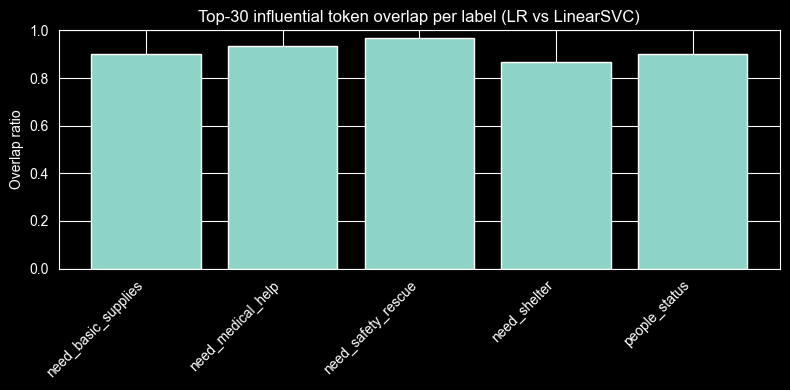

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feat_svc = np.array(best_svc["model"].named_steps["tfidf"].get_feature_names_out())
feat_lr  = np.array(best_lr["model"].named_steps["tfidf"].get_feature_names_out())

rows = []
for j, lab in enumerate(labels):
    w_svc = best_svc["model"].named_steps["clf"].estimators_[j].coef_.ravel()
    w_lr  = best_lr["model"].named_steps["clf"].estimators_[j].coef_.ravel()
    top_svc_idx = np.argsort(w_svc)[-30:][::-1]
    top_lr_idx  = np.argsort(w_lr)[-30:][::-1]
    top_svc = list(feat_svc[top_svc_idx])
    top_lr  = list(feat_lr[top_lr_idx])
    overlap = sorted(set(top_lr) & set(top_svc))
    rows.append({"label": lab,"overlap_ratio": len(overlap) / 30})

compare_top30 = pd.DataFrame(rows)
plt.figure(figsize=(8,4))
plt.bar(np.arange(len(compare_top30)), compare_top30["overlap_ratio"].values)
plt.xticks(np.arange(len(compare_top30)), compare_top30["label"].values, rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("Overlap ratio")
plt.title("Top-30 influential token overlap per label (LR vs LinearSVC)")
plt.tight_layout()
plt.show()

The visualisation above shows a strong overlap between the top 30 most influential tokens for both Logistic Regression and Linear SVC. This indicates that the 2 models rely on almost the same vocabulary, which means that they have very similar decision boundaries and explains why their results are so similar.